# VAE (Variational Autoencoder) for Lung Cancer Detection

This notebook trains a VAE model for generating synthetic lung cancer images.

## Model Architecture:
- **Encoder**: Conv2D layers → Latent space (z_mean, z_log_var)
- **Decoder**: Dense → Conv2DTranspose layers → Reconstructed images
- **Output**: Image reconstruction and generation

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os


# TensorFlow configuration
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.18.1
GPU available: []


## Configuration

In [2]:
# Paths
BASE_DIR = Path('../')
LungCancerDetection_DIR = BASE_DIR / 'data' / 'LungCancerDetection' / 'processed'
MODEL_DIR = BASE_DIR / 'models' / 'image' / 'vae'

# Training parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 2e-5

# Class names
CLASS_NAMES = ['benign', 'malignant']

print(f"LungCancerDetection directory: {LungCancerDetection_DIR}")
print(f"Model output directory: {MODEL_DIR}")

LungCancerDetection directory: ..\data\LungCancerDetection\processed
Model output directory: ..\models\image\vae


## Load Dataset

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    str(LungCancerDetection_DIR / 'training'),
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

Found 12860 files belonging to 2 classes.


## Built VAE Model

In [4]:
class VAELungCancer(keras.Model):
    """Variational Autoencoder"""
    
    def __init__(self, latent_dim=200, input_shape=(224, 224, 1), **kwargs):
        super().__init__(**kwargs)
        self.latent_dim = latent_dim
        self.input_shape_val = input_shape
        
        self.encoder = self._build_encoder(input_shape)
        self.sampling = Sampling()
        self.decoder = self._build_decoder(input_shape)
    
    def _build_encoder(self, input_shape):
        inputs = keras.Input(shape=input_shape)
        
        x = layers.Conv2D(64, 4, activation="relu", strides=2, padding="same")(inputs)
        x = layers.BatchNormalization()(x)
        
        x = layers.Conv2D(128, 4, activation="relu", strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        
        x = layers.Conv2D(256, 4, activation="relu", strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        
        x = layers.Conv2D(256, 4, activation="relu", strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        
        x = layers.Flatten()(x)
        
        z_mean = layers.Dense(self.latent_dim, name="z_mean")(x)
        z_log_var = layers.Dense(self.latent_dim, name="z_log_var")(x)
        
        encoder = Model(inputs, [z_mean, z_log_var], name="encoder")
        return encoder
    
    def _build_decoder(self, input_shape):
        latent_inputs = keras.Input(shape=(self.latent_dim,))
        
        x = layers.Dense(14 * 14 * 256, activation="relu")(latent_inputs)
        x = layers.Reshape((14, 14, 256))(x)
        
        x = layers.Conv2DTranspose(256, 3, activation="relu", strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        
        x = layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        
        x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        
        x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        
        outputs = layers.Conv2D(input_shape[-1], 3, activation="sigmoid", padding="same")(x)
        
        decoder = Model(latent_inputs, outputs, name="decoder")
        return decoder
    
    def call(self, x):
        z_mean, z_log_var = self.encoder(x)
        z = self.sampling([z_mean, z_log_var])
        reconstructed = self.decoder(z)
        return reconstructed, z_mean, z_log_var
    
    def loss_function(self, x, reconstructed, z_mean, z_log_var):
        reconstruction_loss = keras.losses.binary_crossentropy(
            tf.reshape(x, [-1, np.prod(x.shape[1:])]),
            tf.reshape(reconstructed, [-1, np.prod(reconstructed.shape[1:])])
        )
        reconstruction_loss *= np.prod(x.shape[1:])
        
        kl_loss = -0.5 * tf.reduce_sum(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
            axis=1
        )
        
        return tf.reduce_mean(reconstruction_loss + kl_loss)


class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [5]:
vae = VAELungCancer(latent_dim=200, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
vae.encoder.summary()
vae.decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      3,136 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │    131,200 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │    524,544 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 14, 14,    │  1,048,832 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50176)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 200)       │ 10,035,400 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 200)       │ 10,035,400 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,781,328 (83.09 MB)

 Trainable params: 21,779,920 (83.08 MB)

 Non-trainable params: 1,408 (5.50 KB)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50176)          │    10,085,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 28, 28, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 56, 56, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 112, 112, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 224, 224, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,065,539 (42.21 MB)

 Trainable params: 11,064,579 (42.21 MB)

 Non-trainable params: 960 (3.75 KB)

In [6]:
# Compile VAE with optimizer
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE))
print("VAE compiled successfully!")

VAE compiled successfully!


## Train Model

In [7]:
@tf.function
def train_step_vae(x):
    with tf.GradientTape() as tape:
        reconstructed, z_mean, z_log_var = vae(x)
        loss = vae.loss_function(x, reconstructed, z_mean, z_log_var)
    
    grads = tape.gradient(loss, vae.trainable_weights)
    vae.optimizer.apply_gradients(zip(grads, vae.trainable_weights))
    return loss

print("\nEntraînement du VAE...")
epochs_vae = 10

for epoch in range(epochs_vae):
    total_loss = 0
    num_batches = 0
    
    for images, labels in train_ds:
        loss = train_step_vae(images)
        total_loss += loss
        num_batches += 1
    
    print(f"Epoch {epoch+1}/{epochs_vae}, VAE Loss: {total_loss/num_batches:.4f}")


Entraînement du VAE...


KeyboardInterrupt: 

## Generate Synthetic Images for Data Augmentation

In [8]:
# Configuration for synthetic image generation
SYNTHETIC_DATA_DIR = BASE_DIR / 'data' / 'LungCancerDetection' / 'synthetic'
SYNTHETIC_TRAIN_DIR = SYNTHETIC_DATA_DIR / 'training'
NUM_SYNTHETIC_IMAGES = 500  # Number of synthetic images to generate per class

print(f"Synthetic data directory: {SYNTHETIC_DATA_DIR}")
print(f"Number of images per class: {NUM_SYNTHETIC_IMAGES}")


Synthetic data directory: ..\data\LungCancerDetection\synthetic
Number of images per class: 500


In [9]:
def generate_and_save_synthetic_images(decoder, num_images, class_name, output_dir):
    """Generate synthetic images using VAE decoder and save them to disk"""
    print(f"Generating {num_images} synthetic images for class '{class_name}'...")
    
    # Create output directory
    class_dir = output_dir / class_name
    class_dir.mkdir(parents=True, exist_ok=True)
    
    # Generate images in batches
    batch_size = 100
    num_batches = (num_images + batch_size - 1) // batch_size
    
    for batch_idx in range(num_batches):
        current_batch_size = min(batch_size, num_images - batch_idx * batch_size)
        
        # Sample from latent space
        z_samples = np.random.normal(size=(current_batch_size, vae.latent_dim))
        
        # Generate images
        generated_images = decoder.predict(z_samples, verbose=0)
        
        # Save images
        for i, img in enumerate(generated_images):
            img_idx = batch_idx * batch_size + i
            # Convert to uint8 (0-255)
            img_uint8 = (img * 255).astype(np.uint8)
            
            # Save image
            img_path = class_dir / f"synthetic_{img_idx:04d}.png"
            plt.imsave(img_path, img_uint8)
        
        if (batch_idx + 1) % 5 == 0 or batch_idx == num_batches - 1:
            print(f"Generated {min((batch_idx + 1) * batch_size, num_images)}/{num_images} images")
    
    print(f"Saved {num_images} synthetic images to {class_dir}")

# Generate synthetic images for each class
for class_name in CLASS_NAMES:
    generate_and_save_synthetic_images(
        vae.decoder, 
        NUM_SYNTHETIC_IMAGES, 
        class_name, 
        SYNTHETIC_TRAIN_DIR
    )

print(f"\nAll synthetic images generated successfully!")

Generating 500 synthetic images for class 'benign'...
Generated 500/500 images
Saved 500 synthetic images to ..\data\LungCancerDetection\synthetic\training\benign
Generating 500 synthetic images for class 'malignant'...
Generated 500/500 images
Saved 500 synthetic images to ..\data\LungCancerDetection\synthetic\training\malignant

All synthetic images generated successfully!



Visualizing sample synthetic images...


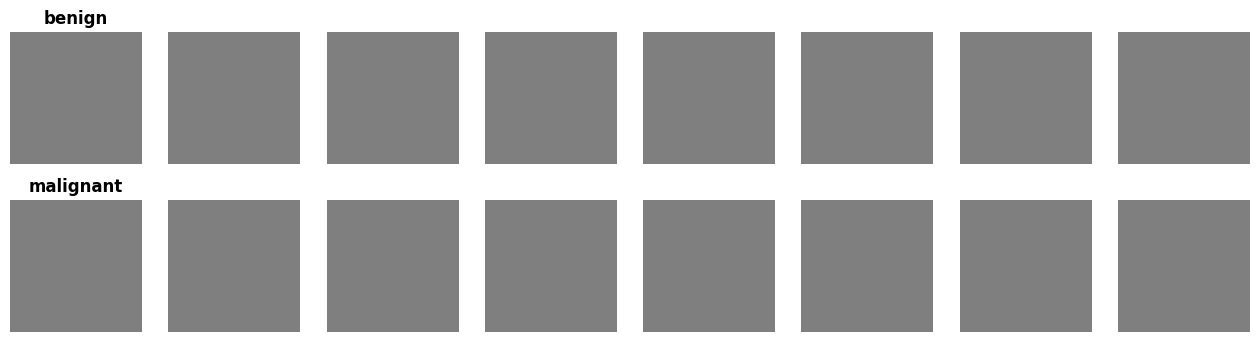

In [14]:
# Visualize sample synthetic images
print("\nVisualizing sample synthetic images...")
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = SYNTHETIC_TRAIN_DIR / class_name
    image_files = sorted(list(class_dir.glob("*.png")))[:8]
    
    for col, img_path in enumerate(image_files):
        img = plt.imread(img_path)
        axes[class_idx, col].imshow(img)
        axes[class_idx, col].axis('off')
        if col == 0:
            axes[class_idx, col].set_title(class_name, fontsize=12, fontweight='bold')


## Save Model

In [ ]:
# Create model directory if it doesn't exist
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save as .keras format
MODEL_PATH = MODEL_DIR / 'vae_encoder.keras'
vae.encoder.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

MODEL_PATH = MODEL_DIR / 'vae_decoder.keras'
vae.decoder.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

# Load the model
loaded_model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded successfully!")
print("Input shape:", loaded_model.input_shape)
print("Output shape:", loaded_model.output_shape)

Model saved to: ../models/audio/mobilenet/mobilenet_model.keras
Model loaded successfully!
Input shape: (None, 224, 224, 3)
Output shape: (None, 1)
